<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/adversarial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3023 files belonging to 2 classes.
Using 2419 files for training.
Found 3023 files belonging to 2 classes.
Using 604 files for validation.



Evaluating baseline model before defense...
Baseline Clean Accuracy: 98.34%
Baseline FGSM Accuracy: 3.99%
Baseline Clean Loss: 0.0651

Starting adversarial training...

Epoch 1/10
loss=15.1953 accuracy=0.4963

Epoch 2/10
loss=14.4383 accuracy=0.4957

Epoch 3/10
loss=13.6603 accuracy=0.4957

Epoch 4/10
loss=12.9208 accuracy=0.4959

Epoch 5/10
loss=12.2311 accuracy=0.4955

Epoch 6/10
loss=11.5760 accuracy=0.4950

Epoch 7/10
loss=10.9572 accuracy=0.4945

Epoch 8/10
loss=10.3705 accuracy=0.4937

Epoch 9/10
loss=9.8063 accuracy=0.4925

Epoch 10/10


loss=9.2598 accuracy=0.4907

Robust model saved to: /content/drive/MyDrive/adv_trained_model.h5

===== FINAL COMPARISON =====
Before Defense:
Clean Accuracy: 98.34%
FGSM Accuracy: 3.99%

After Defense:
Clean Accuracy: 95.20%
FGSM Accuracy: 24.39%
Clean Loss: 0.5617

Classification Report After Defense:
              precision    recall  f1-score   support

          no       0.94      0.96      0.95       298
         yes       0.96      0.94      0.95       306

    accuracy                           0.95       604
   macro avg       0.95      0.95      0.95       604
weighted avg       0.95      0.95      0.95       604



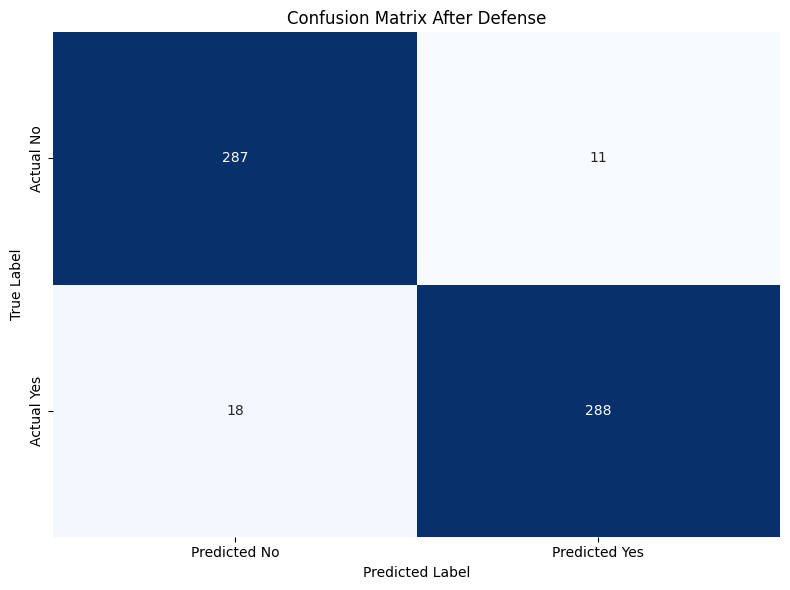

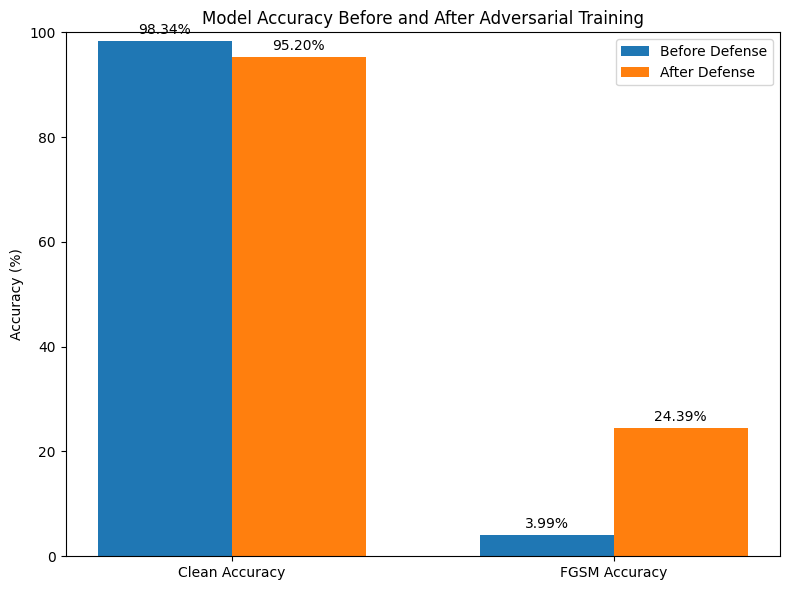

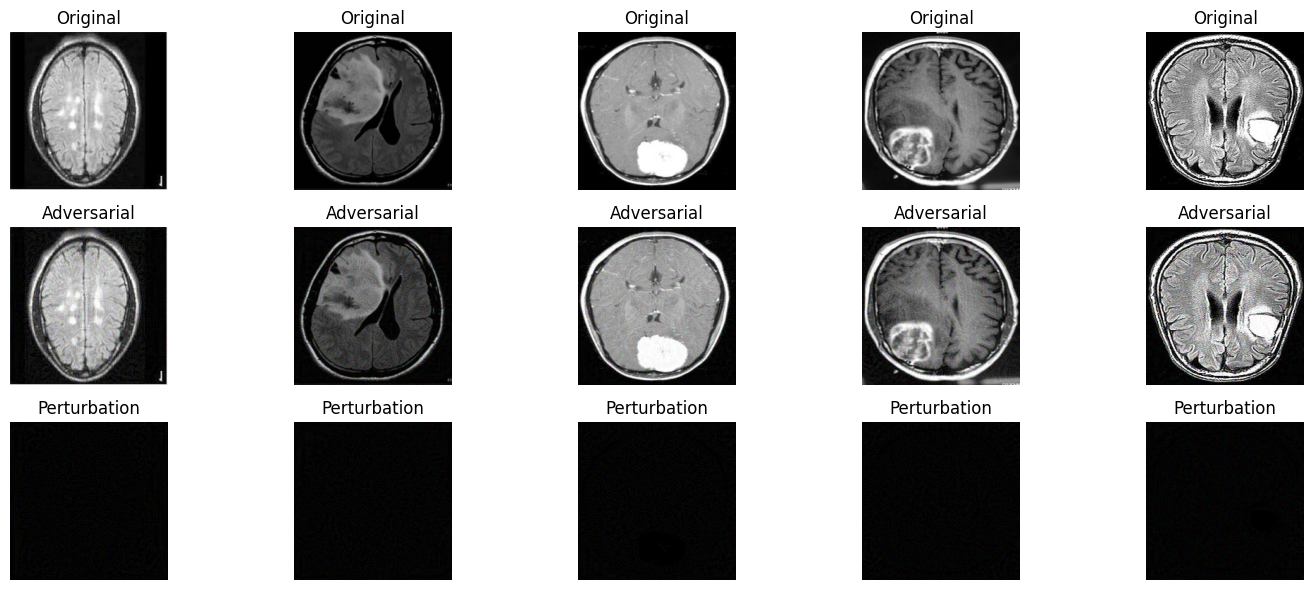

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix


try:
    from google.colab import drive

    drive.mount("/content/drive")
except Exception:
    pass


DATASET_PATH = "/content/drive/MyDrive/Br35H"
BASELINE_MODEL_PATH = "/content/drive/MyDrive/baseline_model.h5"
ROBUST_MODEL_PATH = "/content/drive/MyDrive/adv_trained_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

EPOCHS = 10
EPSILON = 0.04
ALPHA = 0.005
PGD_STEPS = 5
LEARNING_RATE = 1e-5


def prepare_dataset(dataset):
    dataset = dataset.map(
        lambda x, y: (tf.cast(x, tf.float32) / 255.0, tf.cast(y, tf.float32)),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


def load_datasets():
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary",
        class_names=["no", "yes"],
    )

    val_dataset = tf.keras.utils.image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary",
        class_names=["no", "yes"],
    )

    return prepare_dataset(train_dataset), prepare_dataset(val_dataset)


def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def ensure_label_shape(labels):
    labels = tf.cast(labels, tf.float32)
    return tf.reshape(labels, (-1, 1))


def fgsm_attack(model, images, labels, epsilon):
    labels = ensure_label_shape(labels)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images, training=False)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(labels, predictions)
        )

    gradient = tape.gradient(loss, images)
    adv_images = images + epsilon * tf.sign(gradient)
    return tf.clip_by_value(adv_images, 0.0, 1.0)


def pgd_attack(model, images, labels, epsilon, alpha, iterations):
    labels = ensure_label_shape(labels)
    original_images = tf.identity(images)
    adv_images = tf.identity(images)

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions = model(adv_images, training=False)
            loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(labels, predictions)
            )

        gradient = tape.gradient(loss, adv_images)
        adv_images = adv_images + alpha * tf.sign(gradient)
        adv_images = tf.clip_by_value(
            adv_images, original_images - epsilon, original_images + epsilon
        )
        adv_images = tf.clip_by_value(adv_images, 0.0, 1.0)

    return adv_images


def evaluate_under_fgsm(model, dataset, epsilon):
    accuracy_scores = []

    for images, labels in dataset:
        adv_images = fgsm_attack(model, images, labels, epsilon)
        predictions = model.predict(adv_images, verbose=0)
        predicted_labels = (predictions > 0.5).astype(np.int32).reshape(-1)
        true_labels = labels.numpy().astype(np.int32).reshape(-1)
        accuracy_scores.append(np.mean(predicted_labels == true_labels))

    return float(np.mean(accuracy_scores))


def adversarial_train(model, train_dataset, epochs, epsilon, alpha, iterations):
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        epoch_loss = tf.keras.metrics.Mean()
        epoch_accuracy = tf.keras.metrics.Mean()

        for images, labels in train_dataset:
            labels = ensure_label_shape(labels)
            adv_images = pgd_attack(model, images, labels, epsilon, alpha, iterations)

            combined_images = tf.concat([images, adv_images], axis=0)
            combined_labels = tf.concat([labels, labels], axis=0)

            metrics = model.train_on_batch(
                combined_images, combined_labels, return_dict=True
            )
            epoch_loss.update_state(metrics["loss"])
            epoch_accuracy.update_state(metrics["accuracy"])

        print(
            f"loss={epoch_loss.result().numpy():.4f} "
            f"accuracy={epoch_accuracy.result().numpy():.4f}"
        )


def collect_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = (predictions > 0.5).astype(np.int32).reshape(-1)
        true_labels = labels.numpy().astype(np.int32).reshape(-1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    return np.array(y_true), np.array(y_pred)


def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted No", "Predicted Yes"],
        yticklabels=["Actual No", "Actual Yes"],
    )
    plt.title("Confusion Matrix After Defense")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


def plot_comparison(clean_before, fgsm_before, clean_after, fgsm_after):
    labels = ["Clean Accuracy", "FGSM Accuracy"]
    before_values = [clean_before * 100, fgsm_before * 100]
    after_values = [clean_after * 100, fgsm_after * 100]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 6))
    bars_before = ax.bar(x - width / 2, before_values, width, label="Before Defense")
    bars_after = ax.bar(x + width / 2, after_values, width, label="After Defense")

    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Model Accuracy Before and After Adversarial Training")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 100)
    ax.legend()

    for bars in (bars_before, bars_after):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.2f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
            )

    plt.tight_layout()
    plt.show()


def show_sample_attacks(model, dataset, epsilon=0.03, num_images=5):
    for images, labels in dataset.take(1):
        adv_images = fgsm_attack(model, images, labels, epsilon=epsilon)

        plt.figure(figsize=(15, 6))
        for i in range(min(num_images, len(images))):
            plt.subplot(3, num_images, i + 1)
            plt.imshow(images[i])
            plt.title("Original")
            plt.axis("off")

            plt.subplot(3, num_images, i + 1 + num_images)
            plt.imshow(adv_images[i])
            plt.title("Adversarial")
            plt.axis("off")

            plt.subplot(3, num_images, i + 1 + (2 * num_images))
            plt.imshow(adv_images[i] - images[i])
            plt.title("Perturbation")
            plt.axis("off")

        plt.tight_layout()
        plt.show()
        break


def main():
    if not tf.io.gfile.exists(BASELINE_MODEL_PATH):
        raise FileNotFoundError(
            f"Baseline model not found at {BASELINE_MODEL_PATH}. "
            "Run Stage A first and save baseline_model.h5."
        )

    train_dataset, val_dataset = load_datasets()

    baseline_model = compile_model(tf.keras.models.load_model(BASELINE_MODEL_PATH))
    robust_model = compile_model(tf.keras.models.load_model(BASELINE_MODEL_PATH))

    print("\nEvaluating baseline model before defense...")
    clean_loss_before, clean_acc_before = baseline_model.evaluate(val_dataset, verbose=0)
    fgsm_acc_before = evaluate_under_fgsm(baseline_model, val_dataset, EPSILON)

    print(f"Baseline Clean Accuracy: {clean_acc_before * 100:.2f}%")
    print(f"Baseline FGSM Accuracy: {fgsm_acc_before * 100:.2f}%")
    print(f"Baseline Clean Loss: {clean_loss_before:.4f}")

    print("\nStarting adversarial training...")
    adversarial_train(
        robust_model,
        train_dataset,
        epochs=EPOCHS,
        epsilon=EPSILON,
        alpha=ALPHA,
        iterations=PGD_STEPS,
    )

    robust_model.save(ROBUST_MODEL_PATH)
    print(f"\nRobust model saved to: {ROBUST_MODEL_PATH}")

    clean_loss_after, clean_acc_after = robust_model.evaluate(val_dataset, verbose=0)
    fgsm_acc_after = evaluate_under_fgsm(robust_model, val_dataset, EPSILON)

    print("\n===== FINAL COMPARISON =====")
    print("Before Defense:")
    print(f"Clean Accuracy: {clean_acc_before * 100:.2f}%")
    print(f"FGSM Accuracy: {fgsm_acc_before * 100:.2f}%")
    print("\nAfter Defense:")
    print(f"Clean Accuracy: {clean_acc_after * 100:.2f}%")
    print(f"FGSM Accuracy: {fgsm_acc_after * 100:.2f}%")
    print(f"Clean Loss: {clean_loss_after:.4f}")

    y_true, y_pred = collect_predictions(robust_model, val_dataset)
    print("\nClassification Report After Defense:")
    print(classification_report(y_true, y_pred, target_names=["no", "yes"]))

    plot_confusion_matrix(y_true, y_pred)
    plot_comparison(
        clean_acc_before, fgsm_acc_before, clean_acc_after, fgsm_acc_after
    )
    show_sample_attacks(robust_model, val_dataset)


if __name__ == "__main__":
    main()
